# TRAS - C70 Quenched

### Mounting the google drive

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [3]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Pulse_width_experiments/BZ08 pumpmaxx probe change' #Sara's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['Pump 0 Probe 0 2026-03-10 10-12-25 TA.xml', 'Pump max Probe 0 2026-03-10 10-12-25 TA.csv', 'Pump max Probe 0 2026-03-10 10-12-25 TA.xml', 'Pumpmaxx probe 1 2026-03-10 10-20-40 TA.csv', 'Pumpmaxx probe 1 2026-03-10 10-20-40 TA.xml', 'Pumpmaxx probe 2 2026-03-10 10-23-28 TA.csv', 'Pumpmaxx probe 2 2026-03-10 10-23-28 TA.xml', 'pumpmaxx probe 3 2026-03-10 10-26-41 TA.xml', 'pumpmaxx probe 3 2026-03-10 10-26-41 TA.csv', 'pumpmaxx probe 4 2026-03-10 10-30-02 TA.csv', 'pumpmaxx probe 4 2026-03-10 10-30-02 TA.xml', 'pumpmaxx probe 5 2026-03-10 10-33-33 TA.csv', 'pumpmaxx probe 5 2026-03-10 10-33-33 TA.xml', 'pumpmaxx probe 6 2026-03-10 10-37-23 TA.xml', 'pumpmaxx probe 6 2026-03-10 10-37-23 TA.csv', 'pumpmaxx probe 7 2026-03-10 10-40-22 TA.csv', 'pumpmaxx probe 7 2026-03-10 10-40-22 TA.xml', 'BZ08Pump_ProbeChange.ipynb']


## Part 5 - Pulse width using ZnTPP samples

**Keeping concentration and repetition rate constant, investigate the effect of varying the
pulse width of the pump and probe lasers on the structure of the TA curve.
Plotted length of spike against increment**

Skipping bad filename: Pump max Probe 0 2026-03-10 10-12-25 TA.csv


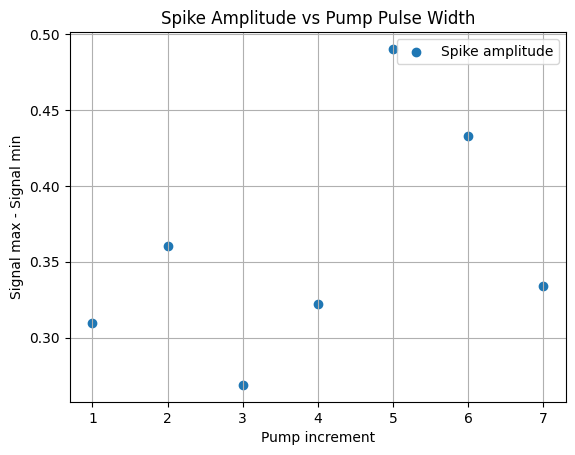

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

signal_max_array = []
signal_min_array = []
increment_array = []
spike_array = []

for file in filelist:
    if not file.endswith(".csv"):
        continue
    if "TA" not in file:
        continue

    csv_title = file

    # ✅ Extract increment from "pump X"
    match = re.search(r"probe\s*(\d+)", csv_title)

    if not match:
        print(f"Skipping bad filename: {csv_title}")
        continue

    increment = int(match.group(1))

    df = pd.read_csv(
        os.path.join(pathTRAS, csv_title),
        sep=";",
        header=None,
        names=["time", "signal"]
    )

    df = df.iloc[1:].reset_index(drop=True)
    df = df.astype(float)

    df_bg = df[df["time"] < -10]
    signal = df_bg["signal"].to_numpy()

    signal_min = np.mean(signal)
    signal_max = np.max(signal)

    signal_max_array.append(signal_max)
    signal_min_array.append(signal_min)

    spike_length = signal_max - signal_min
    spike_array.append(spike_length)
    increment_array.append(increment)


# ✅ Prevent crash if nothing found
if len(increment_array) == 0:
    raise ValueError("No valid files processed — check filename pattern.")


# ✅ Sort
data = sorted(zip(increment_array, spike_array))
increment_array, spike_array = zip(*data)

# ✅ Plot
plt.scatter(increment_array, spike_array, marker='o', label="Spike amplitude")

plt.xlabel("Pump increment")
plt.ylabel("Signal max - Signal min")
plt.title("Spike Amplitude vs Pump Pulse Width")
plt.legend()
plt.grid(True)

plt.show()

## Loading and cleaning data
This step removes the negative bits before the exponential decay.


Processing probe_0 (probe increment 0):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 6.00 ns → σ = 2.55 ns
  Total σ_IRF = 54.84 ns
  Noise σ = 1.2117e+00
  Initial guesses: A=49.5695, τ=540.07 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 54.9294 ± 0.2848
    τ  = 882.17 ± 6.41 ns
    t0 = 55.20 ± 1.08 ns
    χ²_red = 1.0123  |  p = 0.4137  |  R² = 0.990183


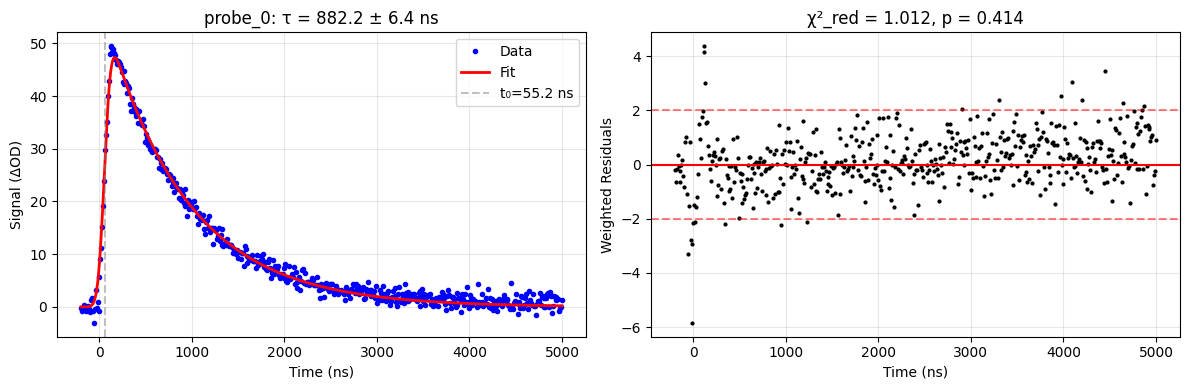


Processing probe_1 (probe increment 1):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 14.20 ns → σ = 6.03 ns
  Total σ_IRF = 55.11 ns
  Noise σ = 1.7811e-01
  Initial guesses: A=50.4406, τ=993.89 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 55.6096 ± 0.0424
    τ  = 863.47 ± 0.92 ns
    t0 = 52.82 ± 0.16 ns
    χ²_red = 14.8139  |  p = 0.0000  |  R² = 0.996957


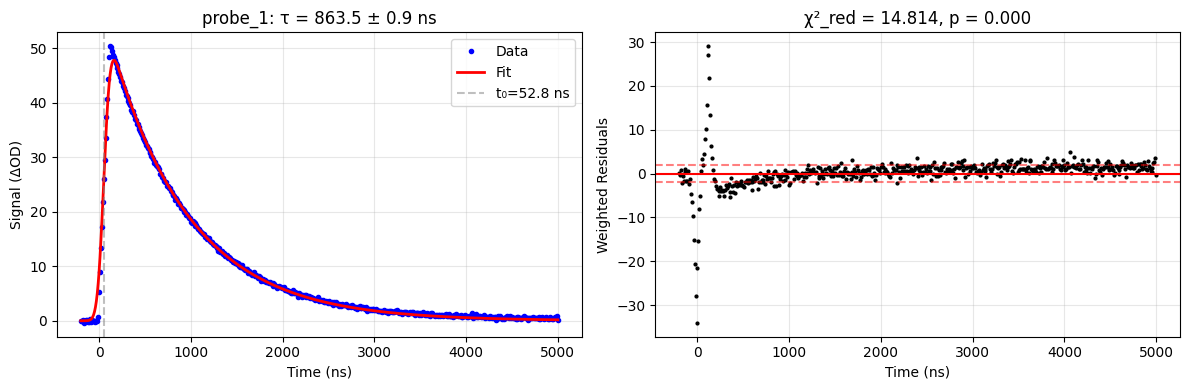


Processing probe_2 (probe increment 2):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 22.40 ns → σ = 9.51 ns
  Total σ_IRF = 55.60 ns
  Noise σ = 1.5942e-01
  Initial guesses: A=50.5937, τ=1011.91 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 55.9871 ± 0.0380
    τ  = 863.60 ± 0.82 ns
    t0 = 51.46 ± 0.14 ns
    χ²_red = 19.3294  |  p = 0.0000  |  R² = 0.996855


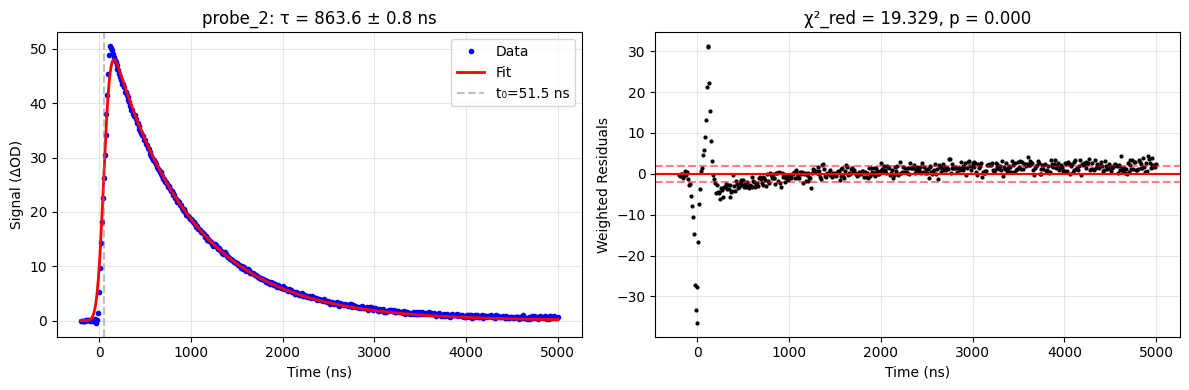


Processing probe_3 (probe increment 3):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 30.60 ns → σ = 12.99 ns
  Total σ_IRF = 56.30 ns
  Noise σ = 1.2892e-01
  Initial guesses: A=50.6293, τ=977.95 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 55.8194 ± 0.0307
    τ  = 864.56 ± 0.67 ns
    t0 = 50.75 ± 0.12 ns
    χ²_red = 30.5738  |  p = 0.0000  |  R² = 0.996737


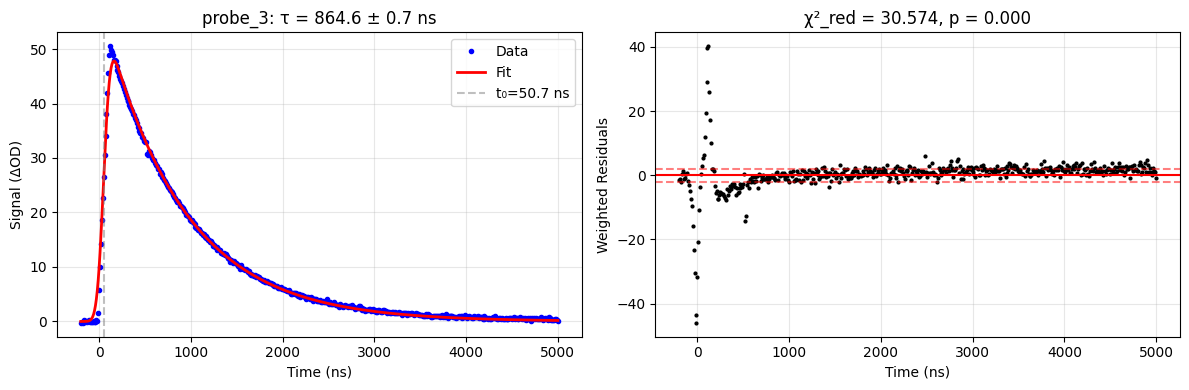


Processing probe_4 (probe increment 4):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 38.80 ns → σ = 16.48 ns
  Total σ_IRF = 57.20 ns
  Noise σ = 1.3999e-01
  Initial guesses: A=50.4978, τ=973.82 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 55.8214 ± 0.0336
    τ  = 859.74 ± 0.72 ns
    t0 = 49.56 ± 0.13 ns
    χ²_red = 27.6398  |  p = 0.0000  |  R² = 0.996504


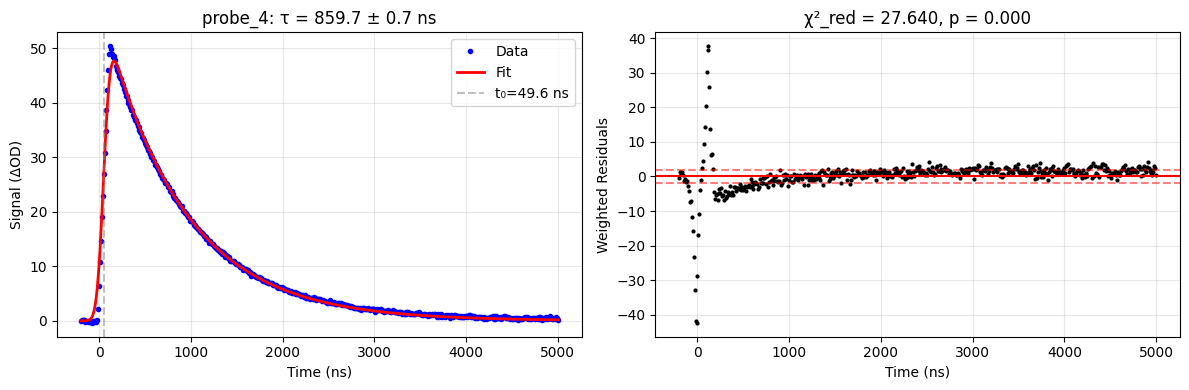


Processing probe_5 (probe increment 5):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 47.00 ns → σ = 19.96 ns
  Total σ_IRF = 58.30 ns
  Noise σ = 1.8093e-01
  Initial guesses: A=49.9759, τ=962.52 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 55.5418 ± 0.0435
    τ  = 856.88 ± 0.94 ns
    t0 = 48.77 ± 0.17 ns
    χ²_red = 16.8711  |  p = 0.0000  |  R² = 0.996388


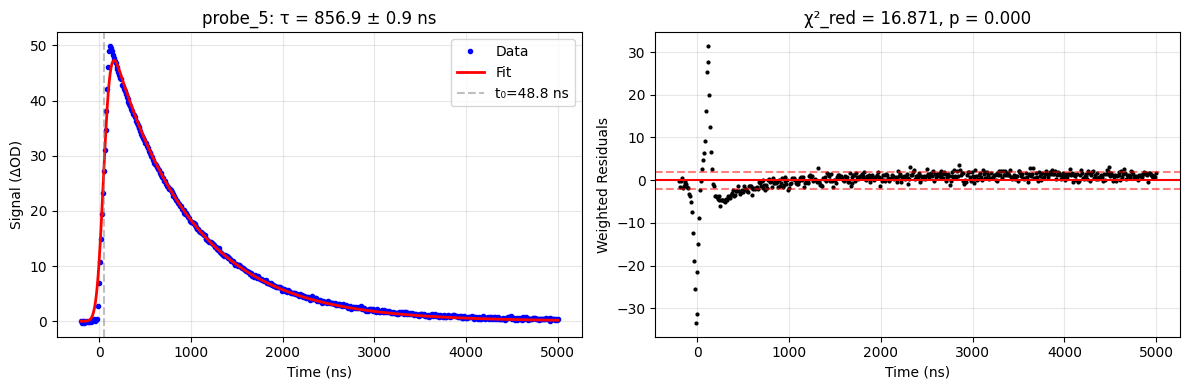


Processing probe_6 (probe increment 6):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 55.20 ns → σ = 23.44 ns
  Total σ_IRF = 59.58 ns
  Noise σ = 1.7152e-01
  Initial guesses: A=49.5503, τ=962.60 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 54.8242 ± 0.0414
    τ  = 856.17 ± 0.91 ns
    t0 = 47.74 ± 0.16 ns
    χ²_red = 21.3583  |  p = 0.0000  |  R² = 0.995772


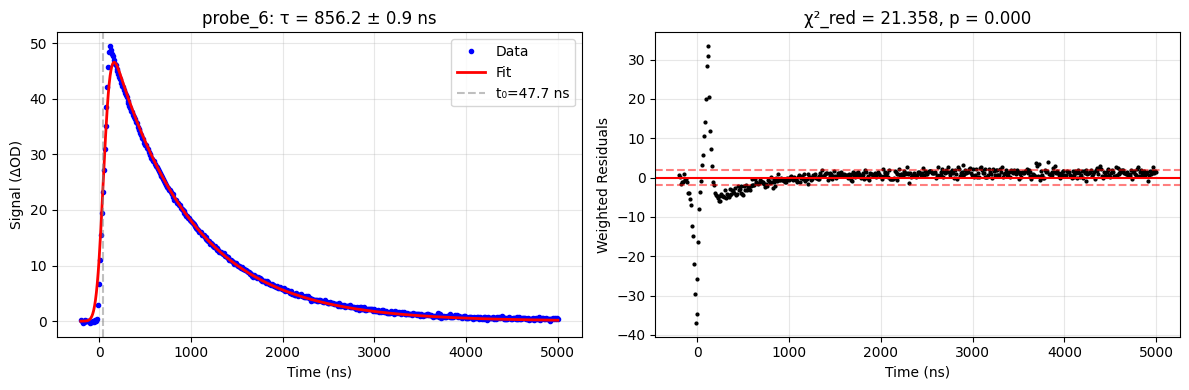


Processing probe_7 (probe increment 7):
  Pump FWHM  = 129.0 ns (fixed max) → σ = 54.78 ns
  Probe FWHM = 63.40 ns → σ = 26.92 ns
  Total σ_IRF = 61.04 ns
  Noise σ = 1.1978e-01
  Initial guesses: A=20.3869, τ=595.20 ns, t0=120.00 ns

  ✅ Fit successful!
    A  = 23.0206 ± 0.0290
    τ  = 856.01 ± 1.51 ns
    t0 = 49.95 ± 0.27 ns
    χ²_red = 8.7853  |  p = 0.0000  |  R² = 0.995208


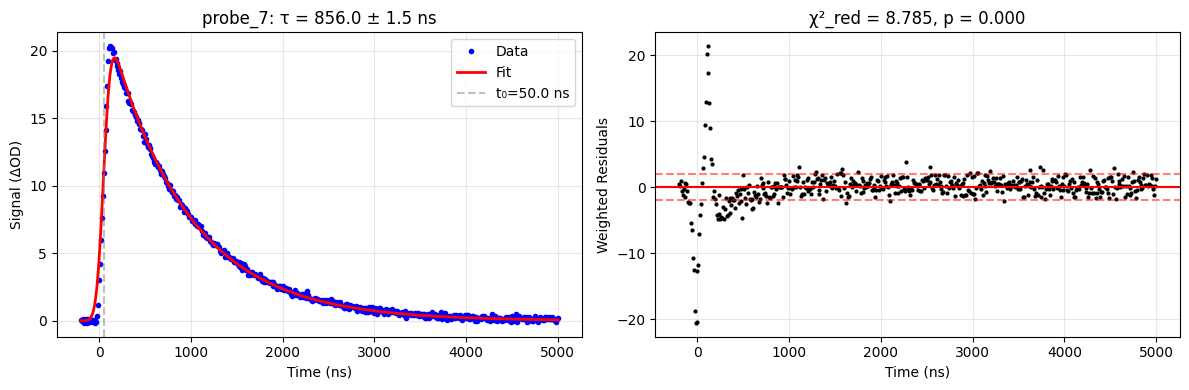


FINAL RESULTS SUMMARY
  Mean τ:          862.8 ± 2.8 ns
  Weighted mean τ: 861.0 ± 0.3 ns
  Std Dev:         8.0 ns
  Range:           856.0 – 882.2 ns
  Mean χ²_red:     17.5480
  Good fits:       1/8


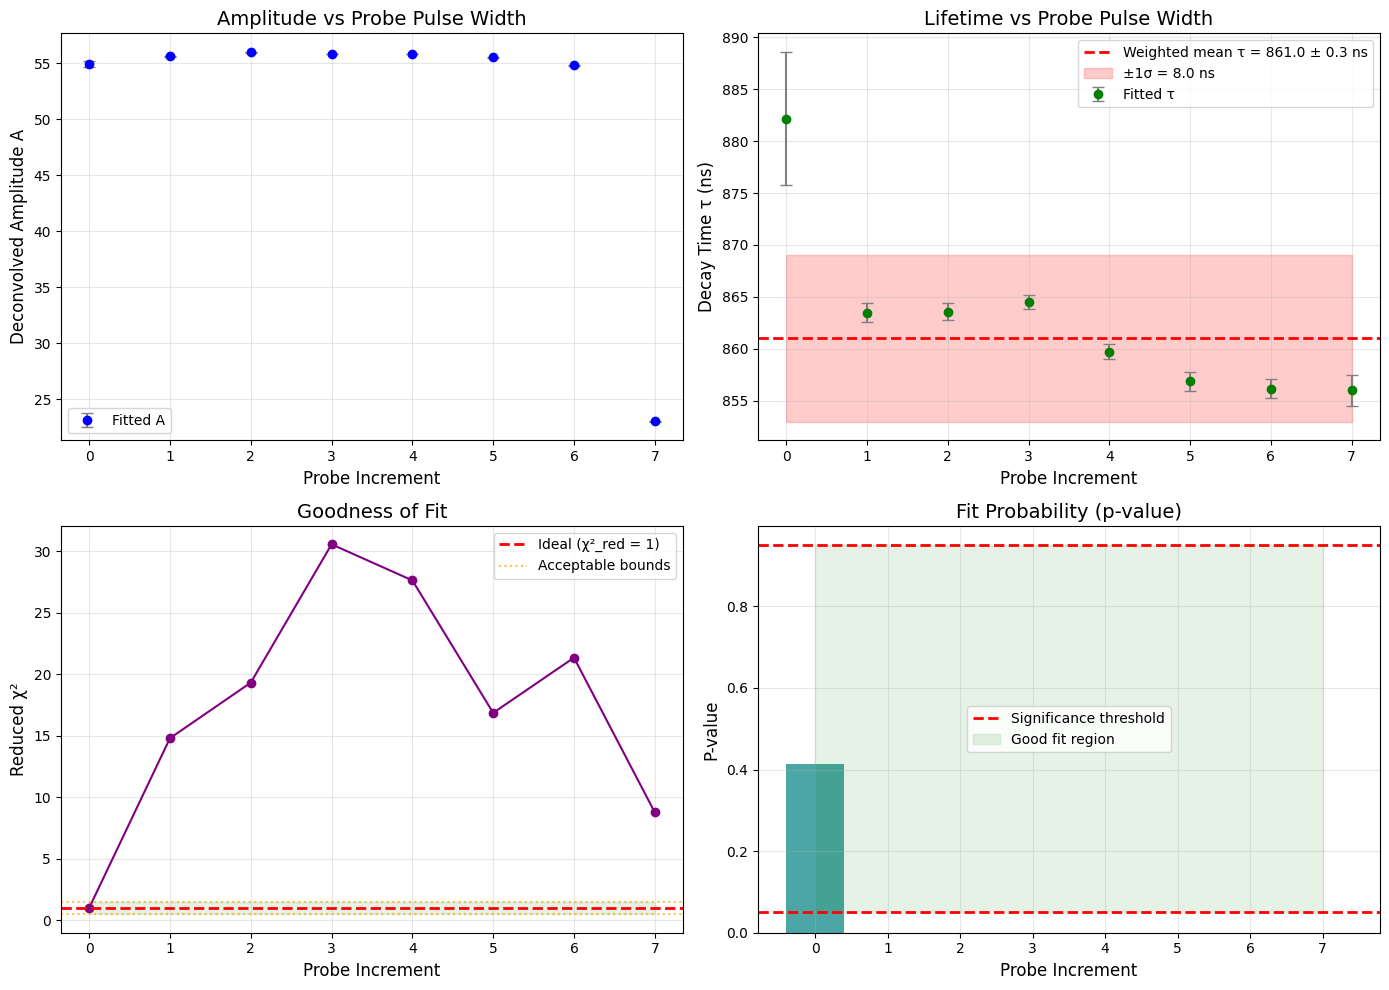


QUALITY ASSESSMENT
⚠️  χ²_red > 1.5 — poor model fit or underestimated errors
✅ Excellent: lifetime highly consistent across probe widths (<5% CV)

Final Lifetime Result: τ = 861.0 ± 0.3 ns
(Weighted average of 8 measurements)


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit
from scipy.special import erfc
from scipy import stats

# ── Constants and Parameters ─────────────────────────────────────────────────────────────
NS_PER_INCREMENT = (129 - 6) / 15   # ~8.2 ns per probe increment (FWHM)
FWHM_TO_SIGMA = 1 / 2.355

# Laser pulse parameters (all in FWHM, ns)
PUMP_FWHM = 129.0                   # Pump is fixed at MAX (increment 15)
BASE_PROBE_FWHM = 6.0               # Base probe pulse width at increment 0 (ns)

def analytical_model(t, A, tau, t0, sigma_irf):
    """
    Exponentially Modified Gaussian (EMG) for kinetics.
    Exact analytical solution for exponential decay convolved with Gaussian IRF.
    """
    tau = max(tau, 1e-6)
    sigma_irf = max(sigma_irf, 1e-6)
    sigma2 = sigma_irf ** 2
    tau2 = tau ** 2
    term1 = sigma2 / (2 * tau2) - (t - t0) / tau
    arg = (sigma2 / tau - (t - t0)) / (np.sqrt(2) * sigma_irf)
    return (A / 2) * np.exp(term1) * erfc(arg)

def calculate_chi_square(y_obs, y_pred, y_err, n_params):
    residuals = y_obs - y_pred
    chi_sq = np.sum((residuals / y_err) ** 2)
    dof = len(y_obs) - n_params
    chi_sq_red = chi_sq / dof if dof > 0 else np.inf
    p_value = 1 - stats.chi2.cdf(chi_sq, dof) if dof > 0 else 0
    return chi_sq, chi_sq_red, p_value

def estimate_measurement_error(signal, window_size=5):
    noise_region = signal[:min(window_size, len(signal))]
    return max(np.std(noise_region), 1e-6)

def get_initial_guesses(t, signal, sigma_irf):
    peak_idx = np.argmax(signal)
    t0_guess = t[peak_idx]
    tau_guess_initial = 860.0       # Updated prior based on previous results
    correction = np.exp(sigma_irf**2 / (2 * tau_guess_initial**2))
    A_guess = signal[peak_idx] * correction
    tail_start_idx = np.searchsorted(t, t0_guess + 3 * sigma_irf)
    if tail_start_idx < len(t) and tail_start_idx + 5 < len(t):
        tail_t = t[tail_start_idx:]
        tail_signal = signal[tail_start_idx:]
        log_signal = np.log(np.maximum(tail_signal, 1e-10))
        if len(tail_t) > 3:
            coeffs = np.polyfit(tail_t - tail_t[0], log_signal, 1)
            tau_guess = -1 / coeffs[0] if coeffs[0] < 0 else tau_guess_initial
        else:
            tau_guess = tau_guess_initial
    else:
        tau_guess = tau_guess_initial
    return A_guess, tau_guess, t0_guess

# ── File Parsing ──────────────────────────────────────────────────────────────────────────
def parse_increment(filename):
    """
    Extract probe increment from filename.
    Handles patterns like:
      - 'probe 0', 'probe 1' ... 'probe 7'  → increments 0-7
      - 'Pump 0'                             → special case, pump-only reference
      - 'Pump max'                           → pump at max, probe at 0 (increment 0)
    Returns (increment, label) or None if not parseable.
    """
    fname = os.path.basename(filename).lower()

    # pumpmaxx probe N  or  Pump max Probe N
    m = re.search(r"probe\s+(\d+)", fname)
    if m:
        return int(m.group(1)), f"probe_{m.group(1)}"

    # "pump max" with no probe number → treat as probe increment 0
    if "pump max" in fname or "pumpmax" in fname:
        return 0, "pump_max_probe0"

    # "pump 0" → reference / dark; skip
    if re.search(r"pump\s+0", fname):
        return None, "pump0_skip"

    return None, "unknown"

# ── Main Processing Loop ──────────────────────────────────────────────────────────────────
increment_array = []
label_array = []
A_array = []
tau_array = []
A_err_array = []
tau_err_array = []
chi_sq_red_array = []
p_value_array = []

for file in sorted(filelist):
    if not (file.endswith(".csv") and "TA" in file):
        continue

    increment, label = parse_increment(file)
    if increment is None:
        print(f"Skipping {file} ({label})")
        continue

    # Read data
    df = pd.read_csv(
        os.path.join(pathTRAS, file),
        sep=";",
        header=None,
        names=["time", "signal"]
    )
    df = df.iloc[1:].reset_index(drop=True).astype(float)

    # Background subtraction
    bg_mask = df["time"] < -10
    bg_mean = df[bg_mask]["signal"].mean() if bg_mask.sum() > 0 else df["signal"].iloc[:10].mean()

    df_roi = df[df["time"] >= -200].copy()
    df_roi["signal_corr"] = df_roi["signal"] - bg_mean

    time_data = df_roi["time"].to_numpy()
    signal_data = df_roi["signal_corr"].to_numpy()

    # Measurement error from pre-trigger
    pre_trigger_mask = time_data < -10
    if pre_trigger_mask.sum() > 5:
        measurement_error = np.std(signal_data[pre_trigger_mask])
    else:
        measurement_error = estimate_measurement_error(signal_data)
    measurement_error = max(measurement_error, 1e-6)

    # ── IRF: pump fixed at max, probe varies ──────────────────────────────────────────
    pump_sigma = PUMP_FWHM * FWHM_TO_SIGMA
    probe_fwhm = BASE_PROBE_FWHM + increment * NS_PER_INCREMENT
    probe_sigma = probe_fwhm * FWHM_TO_SIGMA
    sigma_irf = np.sqrt(pump_sigma**2 + probe_sigma**2)

    print(f"\n{'='*60}")
    print(f"Processing {label} (probe increment {increment}):")
    print(f"  Pump FWHM  = {PUMP_FWHM:.1f} ns (fixed max) → σ = {pump_sigma:.2f} ns")
    print(f"  Probe FWHM = {probe_fwhm:.2f} ns → σ = {probe_sigma:.2f} ns")
    print(f"  Total σ_IRF = {sigma_irf:.2f} ns")
    print(f"  Noise σ = {measurement_error:.4e}")

    def model_fixed_irf(t, A, tau, t0):
        return analytical_model(t, A, tau, t0, sigma_irf)

    A_guess, tau_guess, t0_guess = get_initial_guesses(time_data, signal_data, sigma_irf)
    print(f"  Initial guesses: A={A_guess:.4f}, τ={tau_guess:.2f} ns, t0={t0_guess:.2f} ns")

    try:
        popt, pcov = curve_fit(
            model_fixed_irf,
            time_data,
            signal_data,
            p0=[A_guess, tau_guess, t0_guess],
            bounds=([0, 10, time_data[0]], [np.inf, 5000, time_data[-1]]),
            maxfev=10000,
            sigma=measurement_error * np.ones_like(signal_data),
            absolute_sigma=True
        )

        perr = np.sqrt(np.diag(pcov))
        A_fit, tau_fit, t0_fit = popt
        A_err, tau_err, t0_err = perr

        fitted_signal = model_fixed_irf(time_data, A_fit, tau_fit, t0_fit)
        chi_sq, chi_sq_red, p_value = calculate_chi_square(
            signal_data, fitted_signal,
            measurement_error * np.ones_like(signal_data),
            n_params=3
        )

        ss_res = np.sum((signal_data - fitted_signal)**2)
        ss_tot = np.sum((signal_data - np.mean(signal_data))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        print(f"\n  ✅ Fit successful!")
        print(f"    A  = {A_fit:.4f} ± {A_err:.4f}")
        print(f"    τ  = {tau_fit:.2f} ± {tau_err:.2f} ns")
        print(f"    t0 = {t0_fit:.2f} ± {t0_err:.2f} ns")
        print(f"    χ²_red = {chi_sq_red:.4f}  |  p = {p_value:.4f}  |  R² = {r_squared:.6f}")

        increment_array.append(increment)
        label_array.append(label)
        A_array.append(A_fit)
        tau_array.append(tau_fit)
        A_err_array.append(A_err)
        tau_err_array.append(tau_err)
        chi_sq_red_array.append(chi_sq_red)
        p_value_array.append(p_value)

        # Plot every file (only 8 datasets)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(time_data, signal_data, 'bo', markersize=3, label='Data')
        ax1.plot(time_data, fitted_signal, 'r-', linewidth=2, label='Fit')
        ax1.axvline(t0_fit, color='gray', linestyle='--', alpha=0.5, label=f't₀={t0_fit:.1f} ns')
        ax1.set_xlabel('Time (ns)')
        ax1.set_ylabel('Signal (ΔOD)')
        ax1.set_title(f'{label}: τ = {tau_fit:.1f} ± {tau_err:.1f} ns')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        residuals = signal_data - fitted_signal
        ax2.plot(time_data, residuals / measurement_error, 'ko', markersize=2)
        ax2.axhline(0, color='r'); ax2.axhline(2, color='r', linestyle='--', alpha=0.5)
        ax2.axhline(-2, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Weighted Residuals')
        ax2.set_title(f'χ²_red = {chi_sq_red:.3f}, p = {p_value:.3f}')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    except (RuntimeError, ValueError) as e:
        print(f"\n  ❌ Fit failed: {e}")
        continue

# ── Convert to arrays ─────────────────────────────────────────────────────────────────────
increment_array = np.array(increment_array)
A_array        = np.array(A_array)
tau_array      = np.array(tau_array)
A_err_array    = np.array(A_err_array)
tau_err_array  = np.array(tau_err_array)
chi_sq_red_array = np.array(chi_sq_red_array)
p_value_array  = np.array(p_value_array)

# ── Summary Statistics ────────────────────────────────────────────────────────────────────
tau_mean = np.mean(tau_array)
tau_std  = np.std(tau_array)
tau_sem  = tau_std / np.sqrt(len(tau_array))
tau_weighted_mean = np.average(tau_array, weights=1/tau_err_array**2)
tau_weighted_std  = np.sqrt(1 / np.sum(1/tau_err_array**2))
mean_chi_sq_red   = np.mean(chi_sq_red_array)
good_fits = np.sum((chi_sq_red_array > 0.5) & (chi_sq_red_array < 1.5))

# IRF widths for x-axis label
probe_fwhm_array = BASE_PROBE_FWHM + increment_array * NS_PER_INCREMENT
sigma_irf_array  = np.sqrt((PUMP_FWHM * FWHM_TO_SIGMA)**2 + (probe_fwhm_array * FWHM_TO_SIGMA)**2)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")
print(f"  Mean τ:          {tau_mean:.1f} ± {tau_sem:.1f} ns")
print(f"  Weighted mean τ: {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns")
print(f"  Std Dev:         {tau_std:.1f} ns")
print(f"  Range:           {tau_array.min():.1f} – {tau_array.max():.1f} ns")
print(f"  Mean χ²_red:     {mean_chi_sq_red:.4f}")
print(f"  Good fits:       {good_fits}/{len(chi_sq_red_array)}")

# ── Publication Plot ──────────────────────────────────────────────────────────────────────
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Amplitude vs probe increment
ax1.errorbar(increment_array, A_array, yerr=A_err_array,
             fmt='o', capsize=4, markersize=6, color='blue', ecolor='gray', label='Fitted A')
ax1.set_xlabel("Probe Increment", fontsize=12)
ax1.set_ylabel("Deconvolved Amplitude A", fontsize=12)
ax1.set_title("Amplitude vs Probe Pulse Width", fontsize=14)
ax1.legend(); ax1.grid(True, alpha=0.3)

# Lifetime vs probe increment
ax2.errorbar(increment_array, tau_array, yerr=tau_err_array,
             fmt='o', capsize=4, markersize=6, color='green', ecolor='gray', label='Fitted τ')
ax2.axhline(tau_weighted_mean, color='red', linestyle='--', linewidth=2,
            label=f'Weighted mean τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns')
ax2.fill_between(increment_array,
                 tau_weighted_mean - tau_std, tau_weighted_mean + tau_std,
                 alpha=0.2, color='red', label=f'±1σ = {tau_std:.1f} ns')
ax2.set_xlabel("Probe Increment", fontsize=12)
ax2.set_ylabel("Decay Time τ (ns)", fontsize=12)
ax2.set_title("Lifetime vs Probe Pulse Width", fontsize=14)
ax2.legend(); ax2.grid(True, alpha=0.3)

# Reduced chi-square
ax3.plot(increment_array, chi_sq_red_array, 'o-', color='purple', markersize=6)
ax3.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ideal (χ²_red = 1)')
ax3.axhline(0.5, color='orange', linestyle=':', alpha=0.7, label='Acceptable bounds')
ax3.axhline(1.5, color='orange', linestyle=':', alpha=0.7)
ax3.fill_between(increment_array, 0.5, 1.5, alpha=0.1, color='green')
ax3.set_xlabel("Probe Increment", fontsize=12)
ax3.set_ylabel("Reduced χ²", fontsize=12)
ax3.set_title("Goodness of Fit", fontsize=14)
ax3.legend(); ax3.grid(True, alpha=0.3)

# P-values
ax4.bar(increment_array, p_value_array, color='teal', alpha=0.7)
ax4.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Significance threshold')
ax4.axhline(0.95, color='red', linestyle='--', linewidth=2)
ax4.fill_between(increment_array, 0.05, 0.95, alpha=0.1, color='green', label='Good fit region')
ax4.set_xlabel("Probe Increment", fontsize=12)
ax4.set_ylabel("P-value", fontsize=12)
ax4.set_title("Fit Probability (p-value)", fontsize=14)
ax4.legend(); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TRAS_ProbeVariation_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Quality Assessment ────────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("QUALITY ASSESSMENT")
if mean_chi_sq_red < 0.5:
    print("⚠️  χ²_red < 0.5 — overestimated errors or overfitting")
elif mean_chi_sq_red > 1.5:
    print("⚠️  χ²_red > 1.5 — poor model fit or underestimated errors")
else:
    print("✅ χ²_red in ideal range (0.5–1.5)")

cv = np.std(tau_array) / np.mean(tau_array)
if cv < 0.05:
    print("✅ Excellent: lifetime highly consistent across probe widths (<5% CV)")
elif cv < 0.10:
    print("✅ Good: lifetime consistent across probe widths (<10% CV)")
else:
    print("⚠️  Warning: lifetime shows significant variation across probe widths")

print(f"\nFinal Lifetime Result: τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns")
print(f"(Weighted average of {len(tau_array)} measurements)")

probe_0: A = 54.9294 ± 0.2848,  τ = 882.17 ± 6.41 ns,  σ_IRF = 54.84 ns


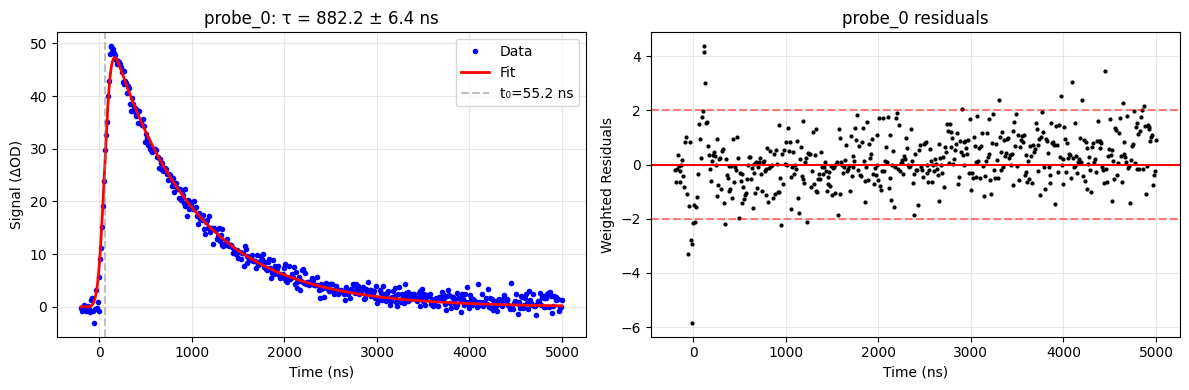

probe_1: A = 55.6096 ± 0.0424,  τ = 863.47 ± 0.92 ns,  σ_IRF = 55.11 ns


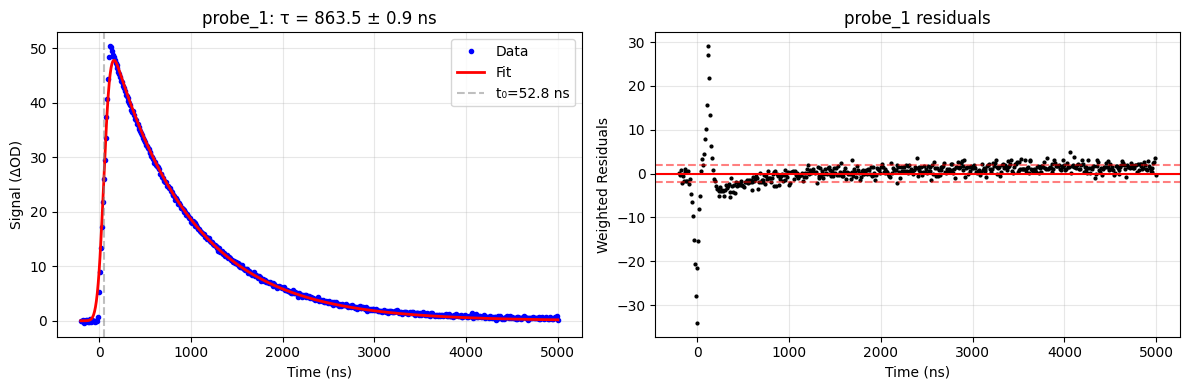

probe_2: A = 55.9871 ± 0.0380,  τ = 863.60 ± 0.82 ns,  σ_IRF = 55.60 ns


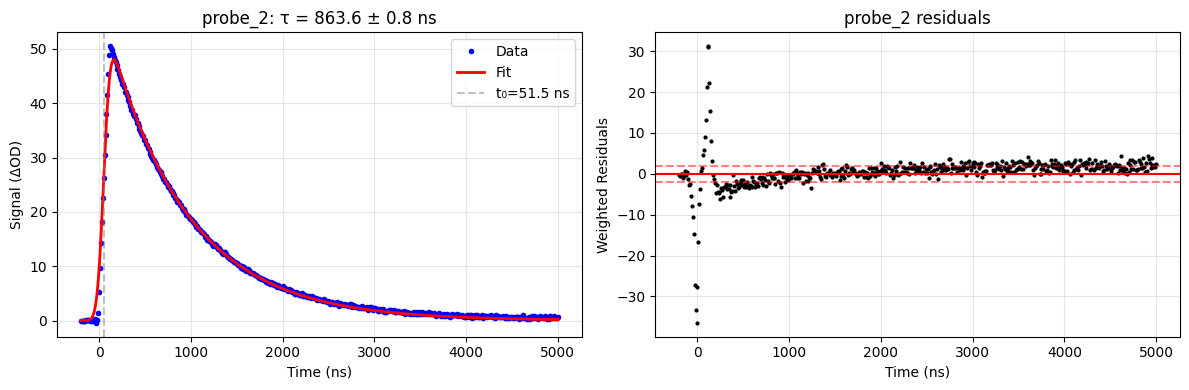

probe_3: A = 55.8194 ± 0.0307,  τ = 864.56 ± 0.67 ns,  σ_IRF = 56.30 ns


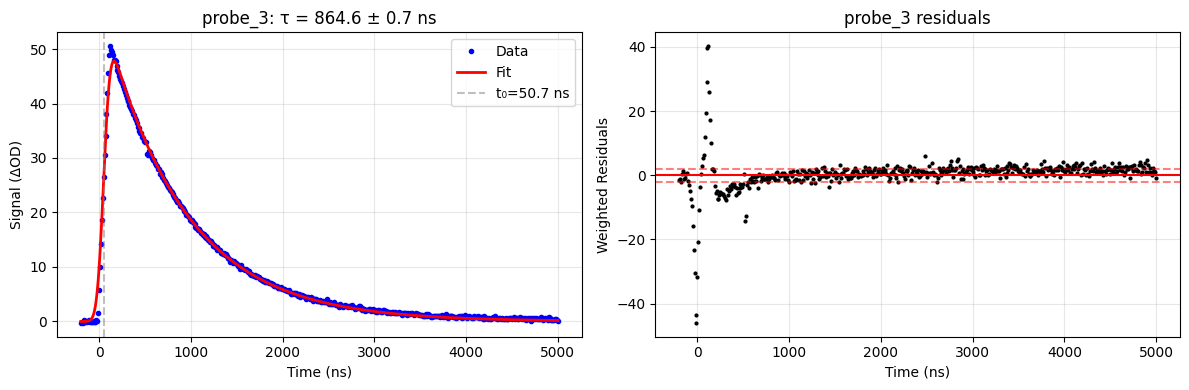

probe_4: A = 55.8214 ± 0.0336,  τ = 859.74 ± 0.72 ns,  σ_IRF = 57.20 ns


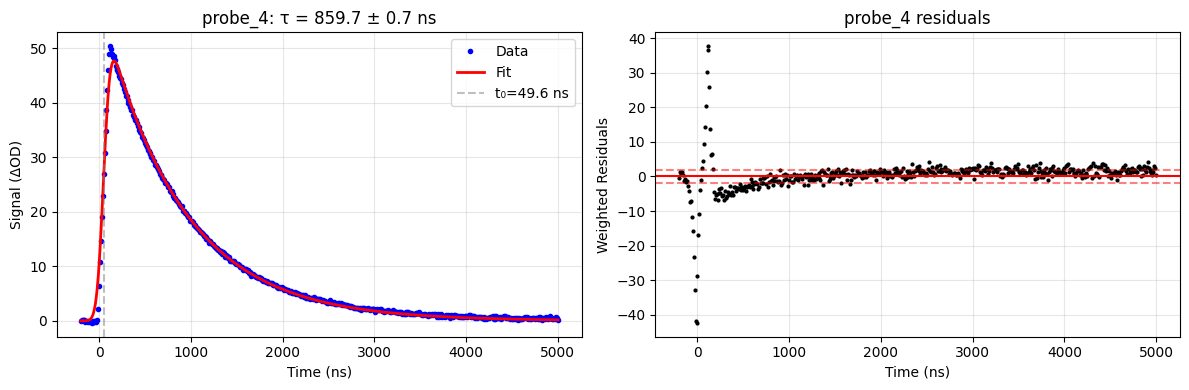

probe_5: A = 55.5418 ± 0.0435,  τ = 856.88 ± 0.94 ns,  σ_IRF = 58.30 ns


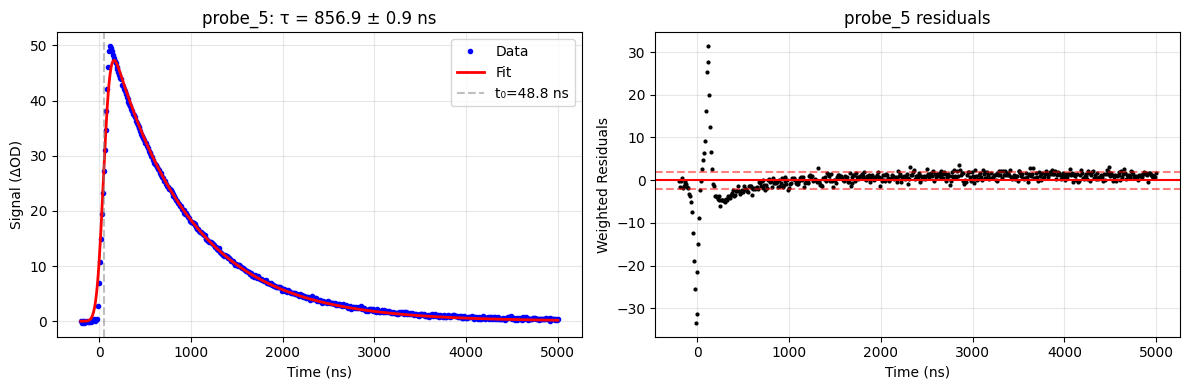

probe_6: A = 54.8242 ± 0.0414,  τ = 856.17 ± 0.91 ns,  σ_IRF = 59.58 ns


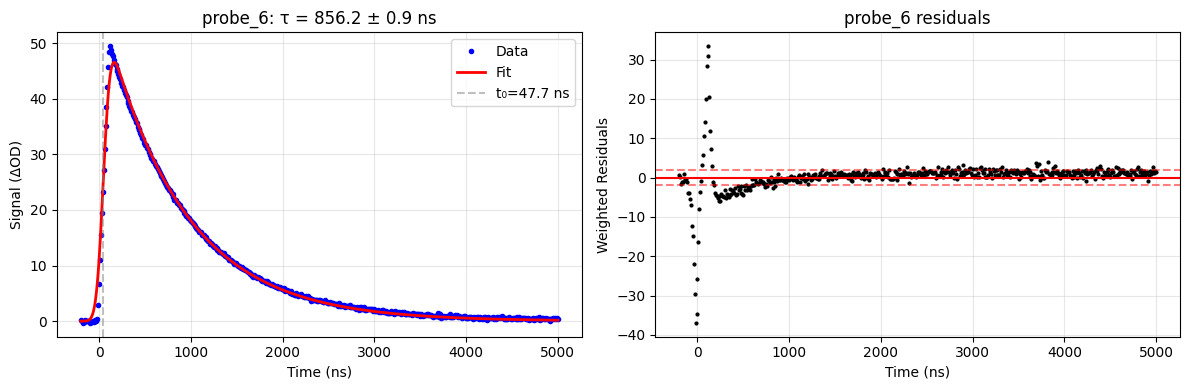

probe_7: A = 23.0206 ± 0.0290,  τ = 856.01 ± 1.51 ns,  σ_IRF = 61.04 ns


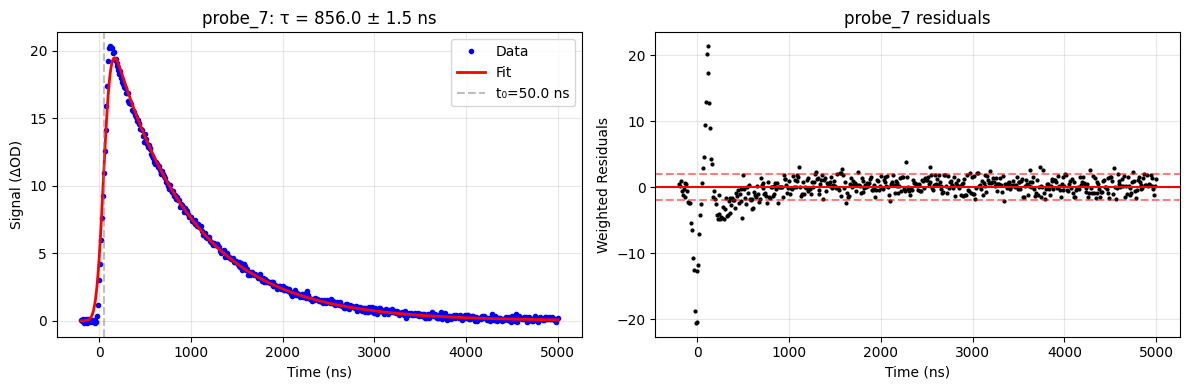


Weighted mean τ = 861.0 ± 0.3 ns
Weighted mean A = 48.5996 ± 0.0135


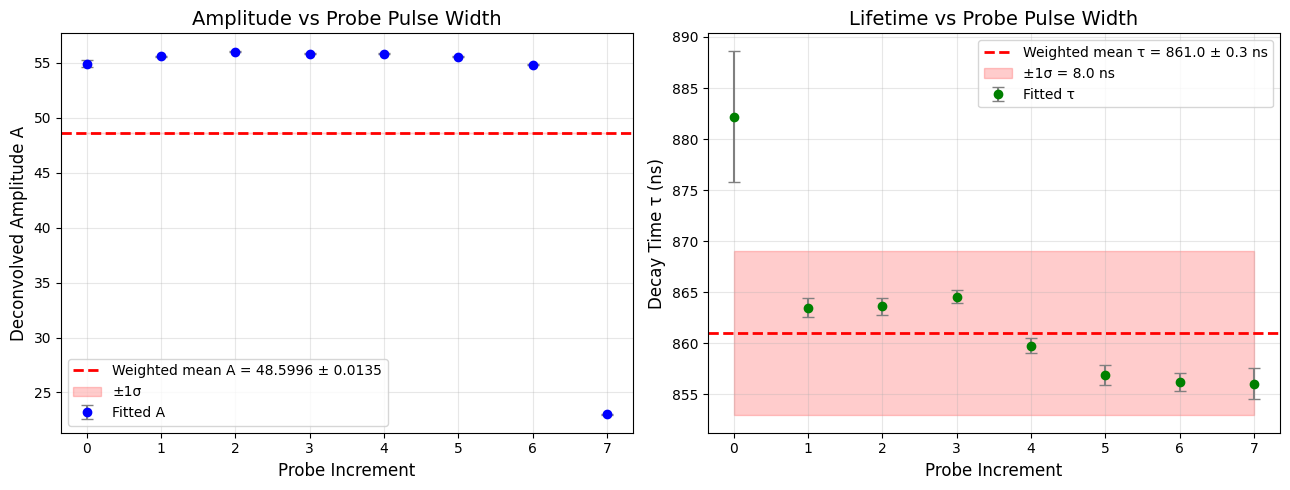

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit
from scipy.special import erfc
from scipy import stats

# ── Constants ─────────────────────────────────────────────────────────────────
NS_PER_INCREMENT = (129 - 6) / 15
FWHM_TO_SIGMA    = 1 / 2.355
PUMP_FWHM        = 129.0
BASE_PROBE_FWHM  = 6.0

def analytical_model(t, A, tau, t0, sigma_irf):
    tau       = max(tau, 1e-6)
    sigma_irf = max(sigma_irf, 1e-6)
    sigma2    = sigma_irf ** 2
    term1     = sigma2 / (2 * tau**2) - (t - t0) / tau
    arg       = (sigma2 / tau - (t - t0)) / (np.sqrt(2) * sigma_irf)
    return (A / 2) * np.exp(term1) * erfc(arg)

def estimate_measurement_error(signal, window_size=5):
    return max(np.std(signal[:min(window_size, len(signal))]), 1e-6)

def get_initial_guesses(t, signal, sigma_irf):
    peak_idx        = np.argmax(signal)
    t0_guess        = t[peak_idx]
    tau_guess_init  = 860.0
    A_guess         = signal[peak_idx] * np.exp(sigma_irf**2 / (2 * tau_guess_init**2))
    tail_start_idx  = np.searchsorted(t, t0_guess + 3 * sigma_irf)
    if tail_start_idx + 5 < len(t):
        tail_t      = t[tail_start_idx:]
        log_signal  = np.log(np.maximum(signal[tail_start_idx:], 1e-10))
        if len(tail_t) > 3:
            coeffs    = np.polyfit(tail_t - tail_t[0], log_signal, 1)
            tau_guess = -1 / coeffs[0] if coeffs[0] < 0 else tau_guess_init
        else:
            tau_guess = tau_guess_init
    else:
        tau_guess = tau_guess_init
    return A_guess, tau_guess, t0_guess

def parse_increment(filename):
    fname = os.path.basename(filename).lower()
    m = re.search(r"probe\s+(\d+)", fname)
    if m:
        return int(m.group(1)), f"probe_{m.group(1)}"
    if "pump max" in fname or "pumpmax" in fname:
        return 0, "pump_max_probe0"
    if re.search(r"pump\s+0", fname):
        return None, "pump0_skip"
    return None, "unknown"

# ── Main Loop ─────────────────────────────────────────────────────────────────
increment_array  = []
A_array          = []
tau_array        = []
A_err_array      = []
tau_err_array    = []

increment, label = parse_increment(file)


for file in sorted(filelist):
    if not (file.endswith(".csv") and "TA" in file):
        continue

    increment, label = parse_increment(file)
    if increment is None:
        print(f"Skipping {file} ({label})")
        continue

    # if increment is None:
    #     print(f"Skipping {file} ({label})")
    #     continue

    # if increment == 7:
    #     print(f"Skipping increment 7: {file}")
    #     continue

    df = pd.read_csv(
        os.path.join(pathTRAS, file),
        sep=";", header=None, names=["time", "signal"]
    )
    df = df.iloc[1:].reset_index(drop=True).astype(float)

    bg_mask  = df["time"] < -10
    bg_mean  = df[bg_mask]["signal"].mean() if bg_mask.sum() > 0 else df["signal"].iloc[:10].mean()
    df_roi   = df[df["time"] >= -200].copy()
    df_roi["signal_corr"] = df_roi["signal"] - bg_mean

    time_data   = df_roi["time"].to_numpy()
    signal_data = df_roi["signal_corr"].to_numpy()

    pre_trigger = time_data < -10
    measurement_error = np.std(signal_data[pre_trigger]) if pre_trigger.sum() > 5 \
                        else estimate_measurement_error(signal_data)
    measurement_error = max(measurement_error, 1e-6)

    pump_sigma  = PUMP_FWHM * FWHM_TO_SIGMA
    probe_sigma = (BASE_PROBE_FWHM + increment * NS_PER_INCREMENT) * FWHM_TO_SIGMA
    sigma_irf   = np.sqrt(pump_sigma**2 + probe_sigma**2)

    def model_fixed_irf(t, A, tau, t0):
        return analytical_model(t, A, tau, t0, sigma_irf)

    A_guess, tau_guess, t0_guess = get_initial_guesses(time_data, signal_data, sigma_irf)

    try:
        popt, pcov = curve_fit(
            model_fixed_irf, time_data, signal_data,
            p0=[A_guess, tau_guess, t0_guess],
            bounds=([0, 10, time_data[0]], [np.inf, 5000, time_data[-1]]),
            maxfev=10000,
            sigma=measurement_error * np.ones_like(signal_data),
            absolute_sigma=True
        )
        perr              = np.sqrt(np.diag(pcov))
        A_fit, tau_fit, t0_fit = popt

        print(f"{label}: A = {A_fit:.4f} ± {perr[0]:.4f},  "
              f"τ = {tau_fit:.2f} ± {perr[1]:.2f} ns,  "
              f"σ_IRF = {sigma_irf:.2f} ns")

        # Per-file trace plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(time_data, signal_data, 'bo', markersize=3, label='Data')
        ax1.plot(time_data, model_fixed_irf(time_data, *popt), 'r-', lw=2, label='Fit')
        ax1.axvline(t0_fit, color='gray', linestyle='--', alpha=0.5, label=f't₀={t0_fit:.1f} ns')
        ax1.set_xlabel('Time (ns)'); ax1.set_ylabel('Signal (ΔOD)')
        ax1.set_title(f'{label}: τ = {tau_fit:.1f} ± {perr[1]:.1f} ns')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        residuals = signal_data - model_fixed_irf(time_data, *popt)
        ax2.plot(time_data, residuals / measurement_error, 'ko', markersize=2)
        ax2.axhline(0, color='r')
        ax2.axhline( 2, color='r', linestyle='--', alpha=0.5)
        ax2.axhline(-2, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Weighted Residuals')
        ax2.set_title(f'{label} residuals')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

        increment_array.append(increment)
        A_array.append(A_fit)
        tau_array.append(tau_fit)
        A_err_array.append(perr[0])
        tau_err_array.append(perr[1])

    except (RuntimeError, ValueError) as e:
        print(f"{label}: fit failed — {e}")
        continue

# ── Arrays ────────────────────────────────────────────────────────────────────
increment_array = np.array(increment_array)
A_array         = np.array(A_array)
tau_array       = np.array(tau_array)
A_err_array     = np.array(A_err_array)
tau_err_array   = np.array(tau_err_array)

# ── Summary ───────────────────────────────────────────────────────────────────
tau_weighted_mean = np.average(tau_array, weights=1/tau_err_array**2)
tau_weighted_std  = np.sqrt(1 / np.sum(1/tau_err_array**2))
A_weighted_mean   = np.average(A_array,   weights=1/A_err_array**2)
A_weighted_std    = np.sqrt(1 / np.sum(1/A_err_array**2))
tau_std           = np.std(tau_array)

print(f"\nWeighted mean τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns")
print(f"Weighted mean A = {A_weighted_mean:.4f} ± {A_weighted_std:.4f}")

# ── Summary Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Amplitude — horizontal line fit (weighted mean)
ax1.errorbar(increment_array, A_array, yerr=A_err_array,
             fmt='o', capsize=4, markersize=6, color='blue', ecolor='gray', label='Fitted A')
ax1.axhline(A_weighted_mean, color='red', linestyle='--', linewidth=2,
            label=f'Weighted mean A = {A_weighted_mean:.4f} ± {A_weighted_std:.4f}')
ax1.fill_between(increment_array,
                 A_weighted_mean - A_weighted_std,
                 A_weighted_mean + A_weighted_std,
                 alpha=0.2, color='red', label='±1σ')
ax1.set_xlabel("Probe Increment", fontsize=12)
ax1.set_ylabel("Deconvolved Amplitude A", fontsize=12)
ax1.set_title("Amplitude vs Probe Pulse Width", fontsize=14)
ax1.legend(); ax1.grid(True, alpha=0.3)

# Lifetime — horizontal line fit (weighted mean)
ax2.errorbar(increment_array, tau_array, yerr=tau_err_array,
             fmt='o', capsize=4, markersize=6, color='green', ecolor='gray', label='Fitted τ')
ax2.axhline(tau_weighted_mean, color='red', linestyle='--', linewidth=2,
            label=f'Weighted mean τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns')
ax2.fill_between(increment_array,
                 tau_weighted_mean - tau_std,
                 tau_weighted_mean + tau_std,
                 alpha=0.2, color='red', label=f'±1σ = {tau_std:.1f} ns')
ax2.set_xlabel("Probe Increment", fontsize=12)
ax2.set_ylabel("Decay Time τ (ns)", fontsize=12)
ax2.set_title("Lifetime vs Probe Pulse Width", fontsize=14)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TRAS_ProbeVariation_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()